## Model benchmarking

After the initial data exploration, I am now focusing on selecting the most effective machine learning architecture. Given the tabular nature of this medical dataset and the existing **class imbalance**, I am evaluating **various ensemble methods**.

My objective is to identify a **model that maximizes predictive performance while maintaining robustness against overfitting**. 
After a  benchmarking process, **LightGBM** emerged as the superior choice for this specific dataset.

## Notebook goals:

- Build a **standardized preprocessing pipeline** to ensure data consistency across all models.

- Benchmark **several classifiers**: Random Forest (Bagging) against Gradient Boosting, XGBoost, LightGBM, and CatBoost (Boosting).

- Select **the optimal model based on the F1-Score (to balance Precision and Recall) and AUC-ROC**.

- Analyze the **F1-Gap** between training and test sets to assess model generalization.
- Analyze the **Confusion Matrix** to prioritize models with the **lowest rates of False Positives and False Negatives**.




## Libraries and Settings

In [50]:
# =========================================
# 0. Imports
# =========================================
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from scipy.stats import chi2_contingency

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_curve,
    roc_auc_score
)
from sklearn.ensemble import RandomForestClassifier

import shap
import warnings
# Silence specifically the LightGBM feature name validation warning
warnings.filterwarnings("ignore", message=".*X does not have valid feature names.*")

In [51]:

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)


## Data loading

In [52]:
# =========================================
# Load data
# =========================================
df = pd.read_csv("alzheimers_disease_data.csv")  

# Quick inspection
display(df.head())
print(df.shape)
print(df.info())

,PatientID,Age,Gender,Ethnicity,EducationLevel,BMI,Smoking,AlcoholConsumption,PhysicalActivity,DietQuality,...,MemoryComplaints,BehavioralProblems,ADL,Confusion,Disorientation,PersonalityChanges,DifficultyCompletingTasks,Forgetfulness,Diagnosis,DoctorInCharge
0,4751,73,0,0,2,22.927749,0,13.297218,6.327112,1.347214,...,0,0,1.725883,0,0,0,1,0,0,XXXConfid
1,4752,89,0,0,0,26.827681,0,4.542524,7.619885,0.518767,...,0,0,2.592424,0,0,0,0,1,0,XXXConfid
2,4753,73,0,3,1,17.795882,0,19.555085,7.844988,1.826335,...,0,0,7.119548,0,1,0,1,0,0,XXXConfid
3,4754,74,1,0,1,33.800817,1,12.209266,8.428001,7.435604,...,0,1,6.481226,0,0,0,0,0,0,XXXConfid
4,4755,89,0,0,0,20.716974,0,18.454356,6.310461,0.795498,...,0,0,0.014691,0,0,1,1,0,0,XXXConfid


(2149, 35)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2149 entries, 0 to 2148
Data columns (total 35 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   PatientID                  2149 non-null   int64  
 1   Age                        2149 non-null   int64  
 2   Gender                     2149 non-null   int64  
 3   Ethnicity                  2149 non-null   int64  
 4   EducationLevel             2149 non-null   int64  
 5   BMI                        2149 non-null   float64
 6   Smoking                    2149 non-null   int64  
 7   AlcoholConsumption         2149 non-null   float64
 8   PhysicalActivity           2149 non-null   float64
 9   DietQuality                2149 non-null   float64
 10  SleepQuality               2149 non-null   float64
 11  FamilyHistoryAlzheimers    2149 non-null   int64  
 12  CardiovascularDisease      2149 non-null   int64  
 13  Diabetes                   2149 non-n

##  Target and columns definition

In [53]:
# =========================================
# 2. Define columns manually
# =========================================
cat_cols = [
    "Gender", "Ethnicity", "EducationLevel", "Smoking",
    "FamilyHistoryAlzheimers", "CardiovascularDisease", "Diabetes", "Depression",
    "HeadInjury", "Hypertension", "MemoryComplaints", "BehavioralProblems",
    "Confusion", "Disorientation", "PersonalityChanges",
    "DifficultyCompletingTasks", "Forgetfulness"
]
cat_cols = [c for c in cat_cols if c in df.columns]

num_cols = [
    "Age", "BMI", "AlcoholConsumption", "PhysicalActivity", "DietQuality", "SleepQuality",
    "SystolicBP", "DiastolicBP", "CholesterolTotal", "CholesterolLDL",
    "CholesterolHDL", "CholesterolTriglycerides", "MMSE", "FunctionalAssessment", "ADL"
]
num_cols = [c for c in num_cols if c in df.columns]

In [54]:
# =========================================
#  Target definition
# =========================================

target_col = "Diagnosis"

# Se il target è stringa tipo 'Demented'/'NonDemented'
if df[target_col].dtype == "object":
    df[target_col] = df[target_col].astype("category").cat.codes

## Train/Test/ Validation split

I implement a ColumnTransformer to automate scaling for numerical features and encoding for categorical ones. This ensures a clean separation between training and validation data, preventing any potential data leakage.

In [55]:
# =========================================
# 4. Split features / target
# =========================================
id_cols = [col for col in ["PatientID", "patient_id", "DoctorID", "doctor_id"] if col in df.columns]
X = df.drop(columns=[target_col] + id_cols, errors="ignore")
y = df[target_col]


categorical_cols = X.select_dtypes(include=["object", "category"]).columns.tolist()
numeric_cols = X.select_dtypes(include=np.number).columns.tolist()

numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(transformers=[
    ("num", numeric_transformer, numeric_cols),
    ("cat", categorical_transformer, categorical_cols)
])


In [56]:
# =========================================
# 5. Model Pipeline & Data Splitting
# =========================================
from sklearn.model_selection import GroupShuffleSplit, train_test_split

# Identify if a grouping column exists (to avoid data leakage between sessions of the same patient)
group_col = "PatientID" if "PatientID" in df.columns else None

if group_col is not None and df[group_col].nunique() < len(df):
    # Group-based split to ensure a patient's data is only in one set
    groups = df[group_col]

    # Step 1: Split off test set (20% of total data)
    gss_test = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
    trainval_idx, test_idx = next(gss_test.split(X, y, groups=groups))

    X_trainval = X.iloc[trainval_idx].copy()
    y_trainval = y.iloc[trainval_idx].copy()
    groups_trainval = groups.iloc[trainval_idx].copy()

    X_test = X.iloc[test_idx].copy()
    y_test = y.iloc[test_idx].copy()

    # Step 2: Split trainval into train (75% of 80% = 60%) and val (25% of 80% = 20%)
    gss_val = GroupShuffleSplit(n_splits=1, test_size=0.25, random_state=42)
    train_idx_rel, val_idx_rel = next(gss_val.split(X_trainval, y_trainval, groups=groups_trainval))

    X_train = X_trainval.iloc[train_idx_rel].copy()
    y_train = y_trainval.iloc[train_idx_rel].copy()

    X_val = X_trainval.iloc[val_idx_rel].copy()
    y_val = y_trainval.iloc[val_idx_rel].copy()

else:
    # Standard stratified split for independent samples (60/20/20 ratio)
    # First split: 80% train+val, 20% test
    X_temp, X_test, y_temp, y_test = train_test_split(
        X, y, test_size=0.2, stratify=y, random_state=42
    )
    # Second split: 75% of temp goes to train (60% total), 25% to validation (20% total)
    X_train, X_val, y_train, y_val = train_test_split(
        X_temp, y_temp, test_size=0.25, stratify=y_temp, random_state=42
    )

# Display the final distribution of the datasets
print(f"{'='*30}")
print("DATA SPLIT SUMMARY")
print(f"{'='*30}")
print(f"Train set shape:      {X_train.shape} ({len(X_train)/len(df):.0%})")
print(f"Validation set shape: {X_val.shape} ({len(X_val)/len(df):.0%})")
print(f"Test set shape:       {X_test.shape} ({len(X_test)/len(df):.0%})")
print(f"{'='*30}")



DATA SPLIT SUMMARY
Train set shape:      (1289, 33) (60%)
Validation set shape: (430, 33) (20%)
Test set shape:       (430, 33) (20%)


In [57]:
# =========================================
#  Leakage Check: Patient Overlap 
# =========================================

id_col = "PatientID" 

if id_col in df.columns:
    # We use .index to look up the IDs in the original dataframe
    # This works whether you used GroupShuffleSplit or train_test_split
    train_ids = set(df.loc[X_train.index, id_col])
    test_ids = set(df.loc[X_test.index, id_col])
    val_ids = set(df.loc[X_val.index, id_col])
    
    # Calculate intersection
    overlap = train_ids.intersection(test_ids, val_ids)
    
    print("--- PATIENT OVERLAP ANALYSIS ---")
    print(f"Unique Patients in Training Set: {len(train_ids)}")
    print(f"Unique Patients in Test Set:     {len(test_ids)}")
    print(f"Unique Patients in Validation Set: {len(val_ids)}")
    
    if len(overlap) == 0:
        print(" SUCCESS: No patient overlap detected. Validation is clean.")
    else:
        print(f" CRITICAL WARNING: {len(overlap)} patients exist in BOTH sets!")
        print(f"Overlapping IDs: {list(overlap)[:10]}...") 
        
    # Check for multiple records per patient
    max_records = df[id_col].value_counts().max()
    if max_records > 1:
        print(f"Note: Some patients have up to {max_records} records in this dataset.")
else:
    print(f"Column '{id_col}' not found. Check your 'id_cols' list.")

--- PATIENT OVERLAP ANALYSIS ---
Unique Patients in Training Set: 1289
Unique Patients in Test Set:     430
Unique Patients in Validation Set: 430
 SUCCESS: No patient overlap detected. Validation is clean.


## Models 



In [58]:
# =========================================
# 6. Models Configuration & Imports
# =========================================
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier

# Define the models and their hyperparameter grids for tuning
models_config = {
    "Logistic Regression": {
        "model": LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42),
        "params": {
            "model__C": [0.1, 1, 10],
            "model__penalty": ["l2"]
        }
    },
    "Random Forest": {
        "model": RandomForestClassifier(class_weight='balanced', random_state=42),
        "params": {
            "model__n_estimators": [100, 300],
            "model__max_depth": [8, 12],
            "model__min_samples_split": [2, 5]
        }
    },
    "XGBoost": {
        # 'eval_metric' is set to avoid warnings in newer XGBoost versions
        "model": XGBClassifier(random_state=42, eval_metric='logloss'), 
        "params": {
            "model__n_estimators": [100, 200],
            "model__learning_rate": [0.01, 0.1],
            "model__max_depth": [3, 6]
        }
    },
    "LightGBM": {
        # 'importance_type' and 'verbose' help manage log output and feature importance
        "model": LGBMClassifier(random_state=42, verbose=-1, importance_type='gain'),
        "params": {
            "model__n_estimators": [100, 200],
            "model__learning_rate": [0.01, 0.1],
            "model__num_leaves": [31, 50]
        }
    },
    "CatBoost": {
        # 'verbose=0' keeps the output clean during training
        "model": CatBoostClassifier(verbose=0, random_state=42),
        "params": {
            "model__iterations": [100, 200],
            "model__learning_rate": [0.01, 0.1],
            "model__depth": [4, 6]
        }
    }
}

print("Model configurations loaded with necessary imports.")

Model configurations loaded with necessary imports.


In [59]:
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import (accuracy_score, precision_score, recall_score, 
                             f1_score, roc_auc_score, confusion_matrix, 
                             ConfusionMatrixDisplay, roc_curve, auc)

results = {}
best_estimators = {}

# Iterate through each model configuration
for name, config in models_config.items():
    print(f"\n{'='*60}")
    print(f"Running GridSearch for: {name}")
    print(f"{'='*60}") # Corrected Syntax here
    
    # Create the pipeline using your existing preprocessor
    pipeline = Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("model", config["model"])
    ])
    
    # GridSearchCV on the training data
    grid = GridSearchCV(pipeline, config["params"], cv=5, scoring='f1', n_jobs=-1)
    grid.fit(X_train, y_train)
    
    # --- Print Best Configuration ---
    print(f"Best parameters found for {name}:")
    print(f"{grid.best_params_}")
    print(f"Best Cross-Validation F1-Score: {grid.best_score_:.4f}")
    
    # Store the best model
    best_model = grid.best_estimator_
    best_estimators[name] = best_model
    
    # Evaluate on Test set
    y_pred_test = best_model.predict(X_test)
    y_proba_test = best_model.predict_proba(X_test)[:, 1]
    
    # Store metrics for comparison
    results[name] = {
        "Accuracy": accuracy_score(y_test, y_pred_test),
        "Precision": precision_score(y_test, y_pred_test),
        "Recall": recall_score(y_test, y_pred_test),
        "F1-Score": f1_score(y_test, y_pred_test),
        "AUC-ROC": roc_auc_score(y_test, y_proba_test),
        "y_proba": y_proba_test,
        "y_pred": y_pred_test
    }

print(f"\n{'='*60}")
print("All models trained and evaluated.")
print(f"{'='*60}")


Running GridSearch for: Logistic Regression
Best parameters found for Logistic Regression:
{'model__C': 10, 'model__penalty': 'l2'}
Best Cross-Validation F1-Score: 0.7742

Running GridSearch for: Random Forest
Best parameters found for Random Forest:
{'model__max_depth': 8, 'model__min_samples_split': 5, 'model__n_estimators': 300}
Best Cross-Validation F1-Score: 0.9010

Running GridSearch for: XGBoost
Best parameters found for XGBoost:
{'model__learning_rate': 0.01, 'model__max_depth': 6, 'model__n_estimators': 200}
Best Cross-Validation F1-Score: 0.9227

Running GridSearch for: LightGBM
Best parameters found for LightGBM:
{'model__learning_rate': 0.01, 'model__n_estimators': 200, 'model__num_leaves': 31}
Best Cross-Validation F1-Score: 0.9223

Running GridSearch for: CatBoost
Best parameters found for CatBoost:
{'model__depth': 4, 'model__iterations': 100, 'model__learning_rate': 0.1}
Best Cross-Validation F1-Score: 0.9366

All models trained and evaluated.


## Confusion Matrices and ROC curves
I am evaluating models based on their ability to **handle imbalanced medical data**. B

eyond standard accuracy, I am looking for a **model that minimizes both False Positives (misdiagnosing healthy individuals) and False Negatives (missing actual cases)**, as both carry **significant clinical consequences**.

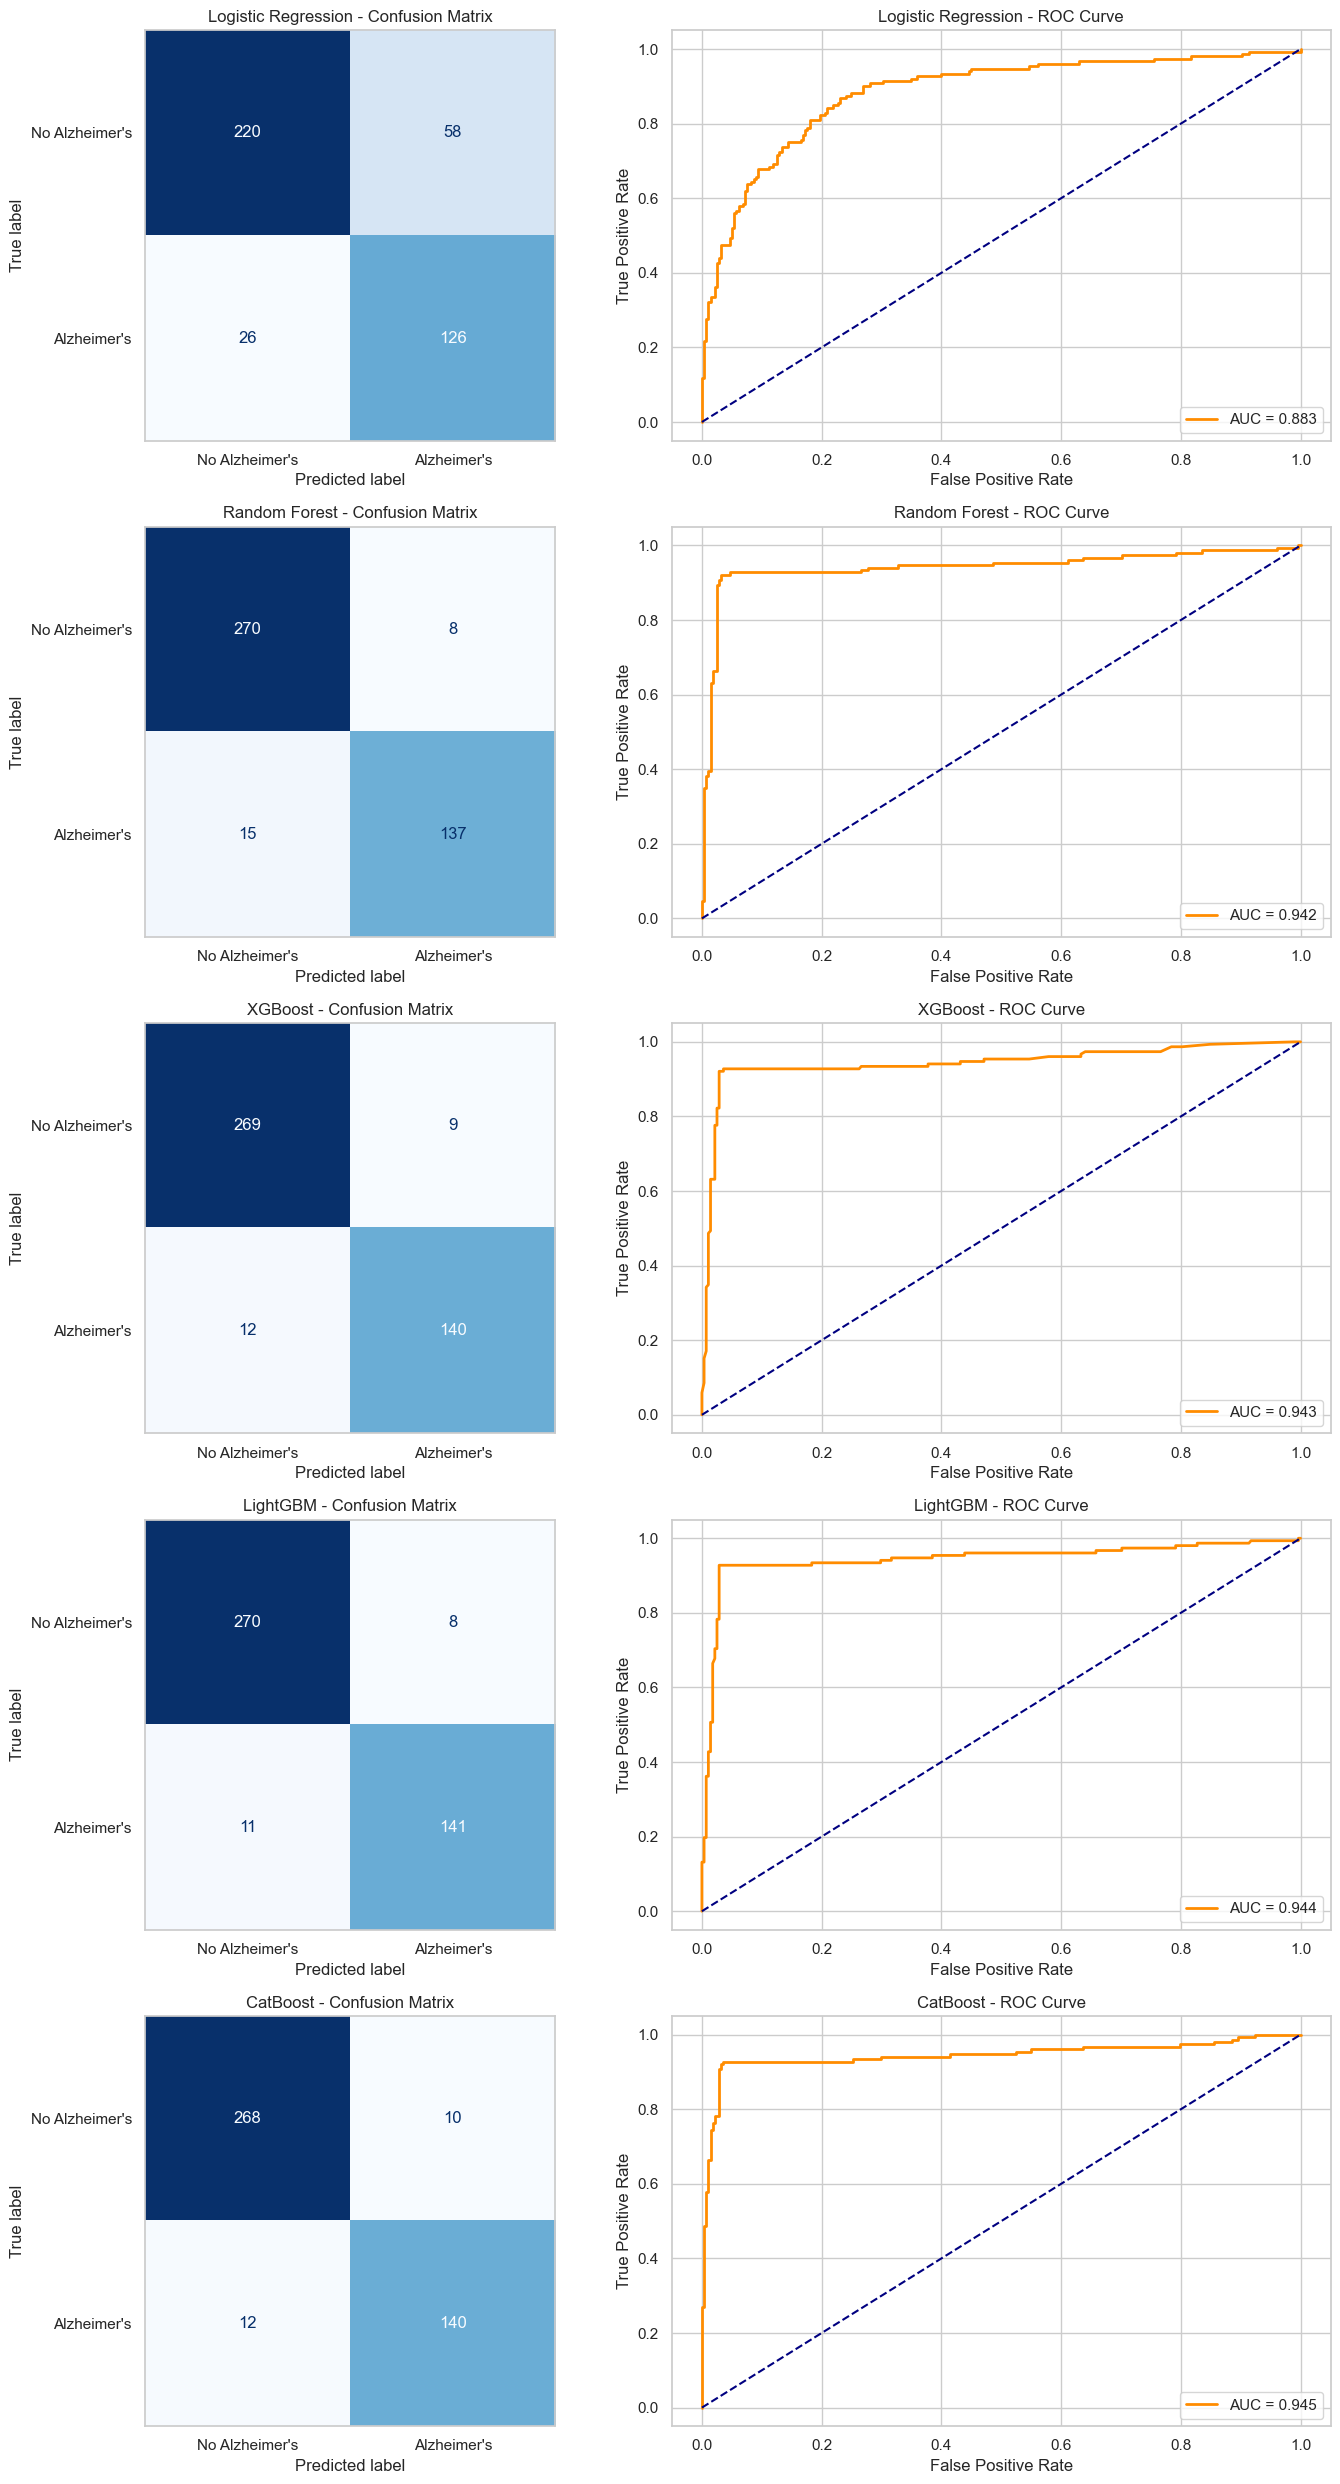

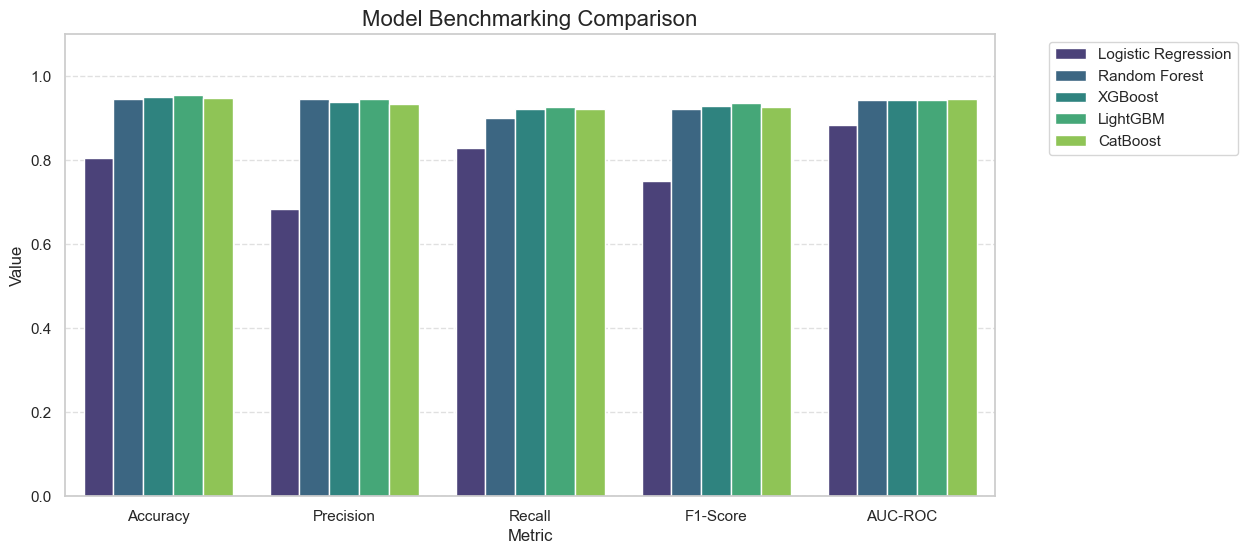

,Accuracy,Precision,Recall,F1-Score,AUC-ROC
LightGBM,0.955814,0.946309,0.927632,0.936877,0.944067
XGBoost,0.951163,0.939597,0.921053,0.930233,0.943499
CatBoost,0.948837,0.933333,0.921053,0.927152,0.945168
Random Forest,0.946512,0.944828,0.901316,0.922559,0.942304
Logistic Regression,0.804651,0.684783,0.828947,0.750000,0.883307


In [60]:
# =========================================
# Confusion Matrices and ROC Curves
# =========================================
fig, axes = plt.subplots(len(results), 2, figsize=(14, 5 * len(results)))
labels = ["No Alzheimer's", "Alzheimer's"]

for i, (name, metrics) in enumerate(results.items()):
    # --- 1. Confusion Matrix (Grid Disabled) ---
    cm = confusion_matrix(y_test, metrics["y_pred"])
    disp = ConfusionMatrixDisplay(cm, display_labels=labels)
    disp.plot(ax=axes[i, 0], cmap='Blues', colorbar=False)
    
    # This line specifically removes the grid for the matrix subplot
    axes[i, 0].grid(False) 
    axes[i, 0].set_title(f"{name} - Confusion Matrix")
    
    # --- 2. ROC Curve ---
    fpr, tpr, _ = roc_curve(y_test, metrics["y_proba"])
    axes[i, 1].plot(fpr, tpr, label=f'AUC = {metrics["AUC-ROC"]:.3f}', color='darkorange', lw=2)
    axes[i, 1].plot([0, 1], [0, 1], color='navy', linestyle='--')
    axes[i, 1].set_title(f"{name} - ROC Curve")
    axes[i, 1].set_xlabel("False Positive Rate")
    axes[i, 1].set_ylabel("True Positive Rate")
    axes[i, 1].legend(loc="lower right")

plt.tight_layout()
plt.show()

# =========================================
# Performance Comparison Bar Chart
# =========================================
df_metrics = pd.DataFrame(results).T.drop(columns=["y_proba", "y_pred"])
df_metrics_long = df_metrics.reset_index().melt(id_vars="index", var_name="Metric", value_name="Value")
df_metrics_long.columns = ["Model", "Metric", "Value"]

plt.figure(figsize=(12, 6))
sns.barplot(data=df_metrics_long, x="Metric", y="Value", hue="Model", palette="viridis")
plt.title("Model Benchmarking Comparison", fontsize=16)
plt.ylim(0, 1.1)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.show()

# Sorted Table with Gradient
display(df_metrics.sort_values(by="F1-Score", ascending=False).style.background_gradient(cmap='YlGn'))

## Evaluation

- After running the initial comparisons, **LightGBM** demonstrated the best overall performance. It consistently produced **fewer False Positives and False Negatives**compared to other ensemble methods, making it the most balanced and trustworthy predictor for this task.

- Calculated the **F1-Gap between** the training and test sets for each model. This metric is crucial for my selection process; **LightGBM showed a highly stable F1-Gap**, indicating that the **performance** achieved on training data is successfully **maintained on unseen data without signs of overfitting**.

- Based on the superior **F1-Score**, the optimized confusion matrix, and the controlled F1-Gap, I have selected LightGBM as the final model. I am now exporting the model object and its metadata to move into the final optimization stage.

In [61]:
import joblib

# Results storage
results = {}
best_estimators = {}

for name, config in models_config.items():
    print(f"Training {name}...")
    
    pipeline = Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("model", config["model"])
    ])
    
    # Grid Search
    grid = GridSearchCV(pipeline, config["params"], cv=5, scoring='f1', n_jobs=-1)
    grid.fit(X_train, y_train)
    
    best_model = grid.best_estimator_
    best_estimators[name] = best_model
    
    # Predictions
    y_train_pred = best_model.predict(X_train)
    y_test_pred = best_model.predict(X_test)
    y_test_proba = best_model.predict_proba(X_test)[:, 1]
    
    # Metrics
    f1_train = f1_score(y_train, y_train_pred)
    f1_test = f1_score(y_test, y_test_pred)
    
    results[name] = {
        "F1_Train": f1_train,
        "F1_Test": f1_test,
        "F1_Gap": f1_train - f1_test, # Il Gap per l'overfitting
        "Accuracy": accuracy_score(y_test, y_test_pred),
        "AUC-ROC": roc_auc_score(y_test, y_test_proba),
        "y_proba": y_test_proba,
        "y_pred": y_test_pred
    }

#dataframe
df_results = pd.DataFrame(results).T.drop(columns=["y_proba", "y_pred"]).sort_values("F1_Test", ascending=False)

Training Logistic Regression...
Training Random Forest...
Training XGBoost...
Training LightGBM...
Training CatBoost...


In [62]:
import joblib

# Results storage
results = {}
best_estimators = {}

for name, config in models_config.items():
    print(f"Training {name}...")
    
    pipeline = Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("model", config["model"])
    ])
    
    # Grid Search
    grid = GridSearchCV(pipeline, config["params"], cv=5, scoring='f1', n_jobs=-1)
    grid.fit(X_train, y_train)
    
    best_model = grid.best_estimator_
    best_estimators[name] = best_model
    
    # Predictions
    y_train_pred = best_model.predict(X_train)
    y_test_pred = best_model.predict(X_test)
    y_test_proba = best_model.predict_proba(X_test)[:, 1]
    
    # Metrics
    f1_train = f1_score(y_train, y_train_pred)
    f1_test = f1_score(y_test, y_test_pred)
    
    results[name] = {
        "F1_Train": f1_train,
        "F1_Test": f1_test,
        "F1_Gap": f1_train - f1_test, # Il Gap per l'overfitting
        "Accuracy": accuracy_score(y_test, y_test_pred),
        "AUC-ROC": roc_auc_score(y_test, y_test_proba),
        "y_proba": y_test_proba,
        "y_pred": y_test_pred
    }

# dataframe
df_results = pd.DataFrame(results).T.drop(columns=["y_proba", "y_pred"]).sort_values("F1_Test", ascending=False)

Training Logistic Regression...
Training Random Forest...
Training XGBoost...
Training LightGBM...
Training CatBoost...


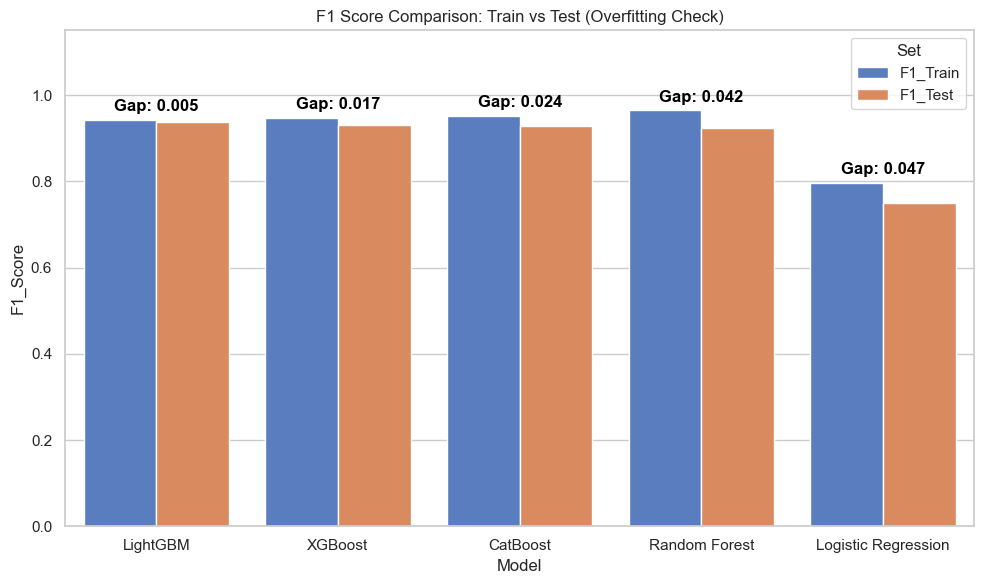

In [63]:
# =========================================
# Overfitting Analysis: Train vs Test F1
# =========================================
plt.figure(figsize=(10, 6))

# Comparation of F1 scores with a bar plot
df_gap = df_results[["F1_Train", "F1_Test"]].reset_index().melt(id_vars="index")
df_gap.columns = ["Model", "Set", "F1_Score"]

sns.barplot(data=df_gap, x="Model", y="F1_Score", hue="Set", palette="muted")

# Annotate the gap on top of the bars
for i, model in enumerate(df_results.index):
    gap = df_results.loc[model, "F1_Gap"]
    plt.text(i, max(df_results.loc[model, "F1_Train"], df_results.loc[model, "F1_Test"]) + 0.02, 
             f"Gap: {gap:.3f}", ha='center', color='red' if gap > 0.1 else 'black', fontweight='bold')

plt.title("F1 Score Comparison: Train vs Test (Overfitting Check)")
plt.ylim(0, 1.15)
plt.tight_layout()
plt.show()

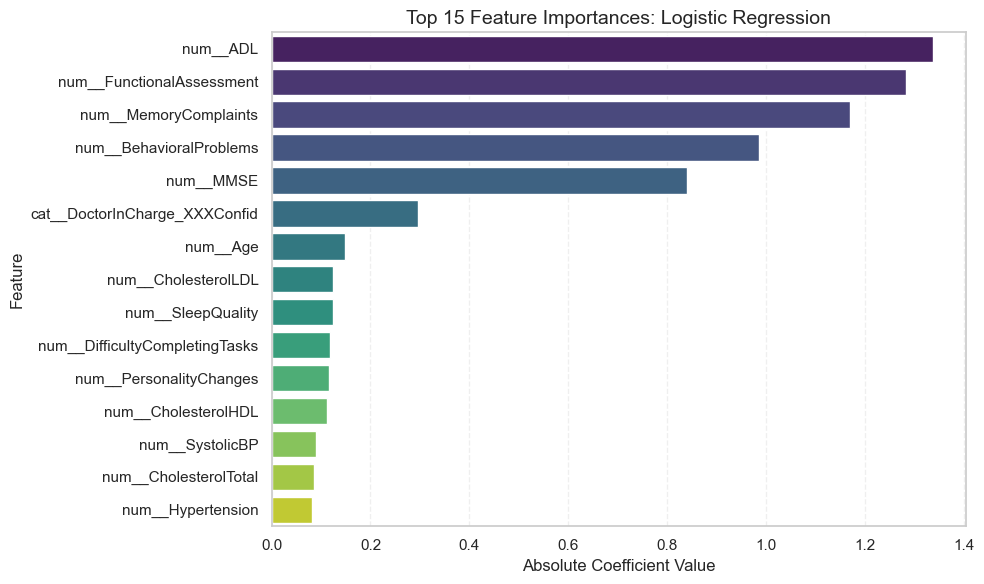

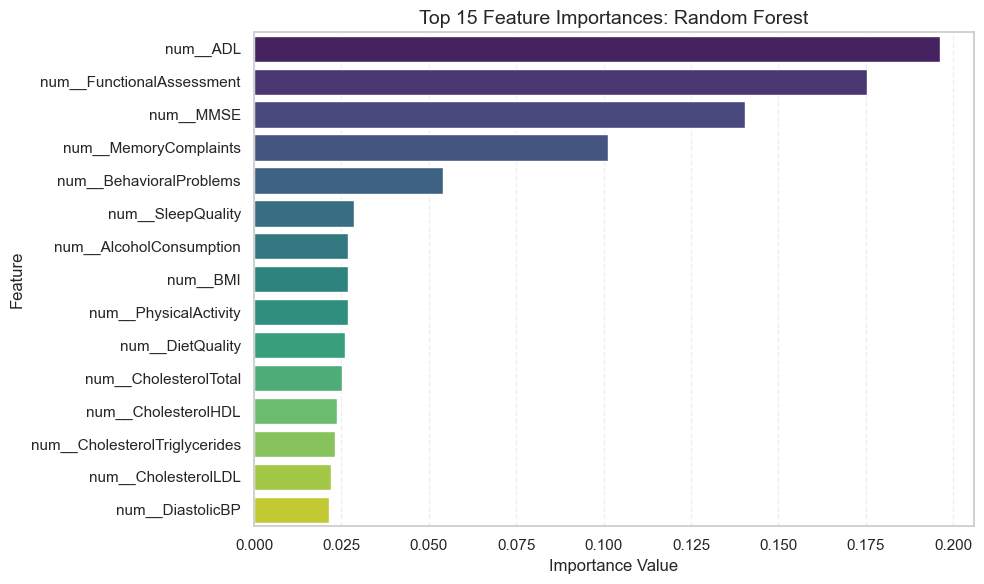

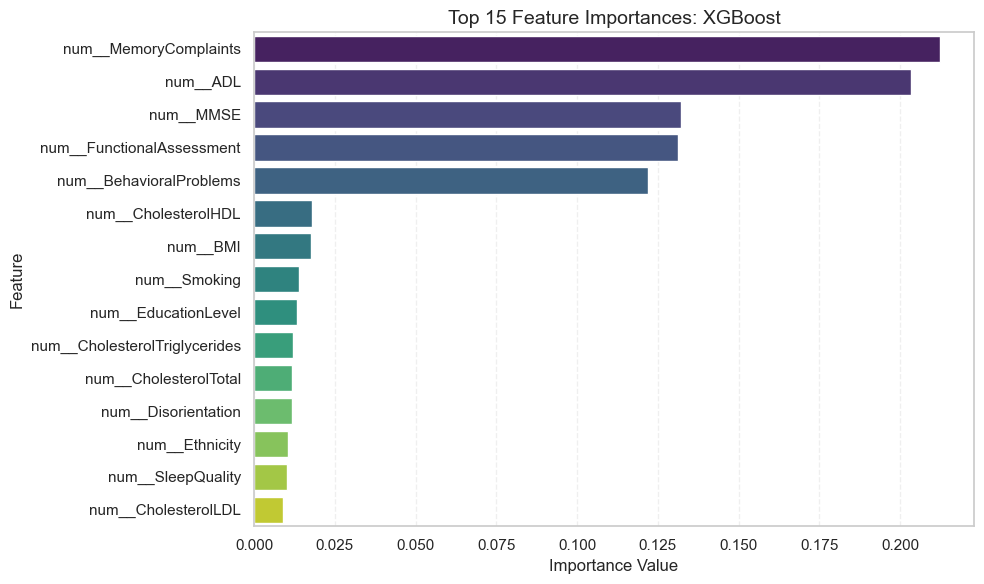

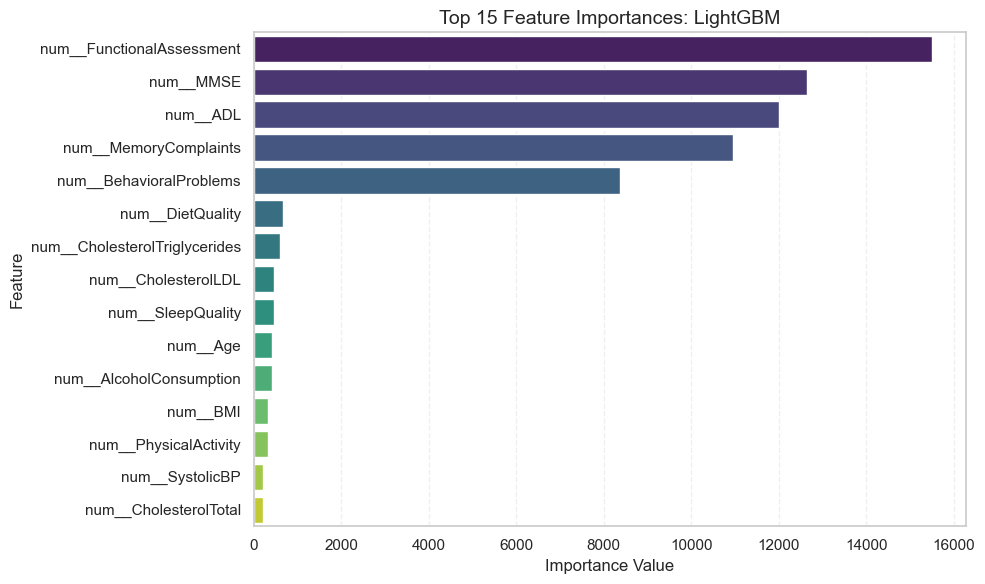

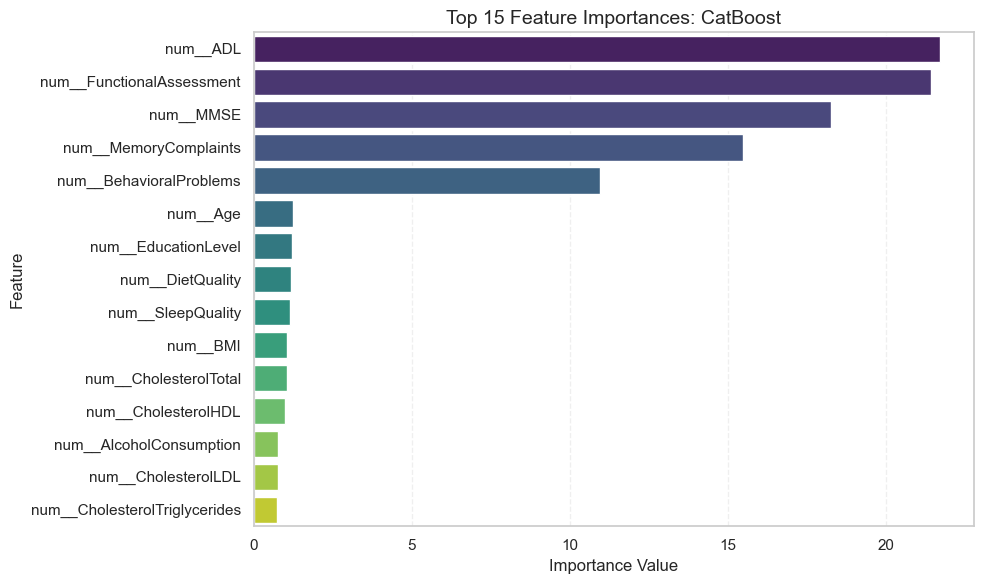

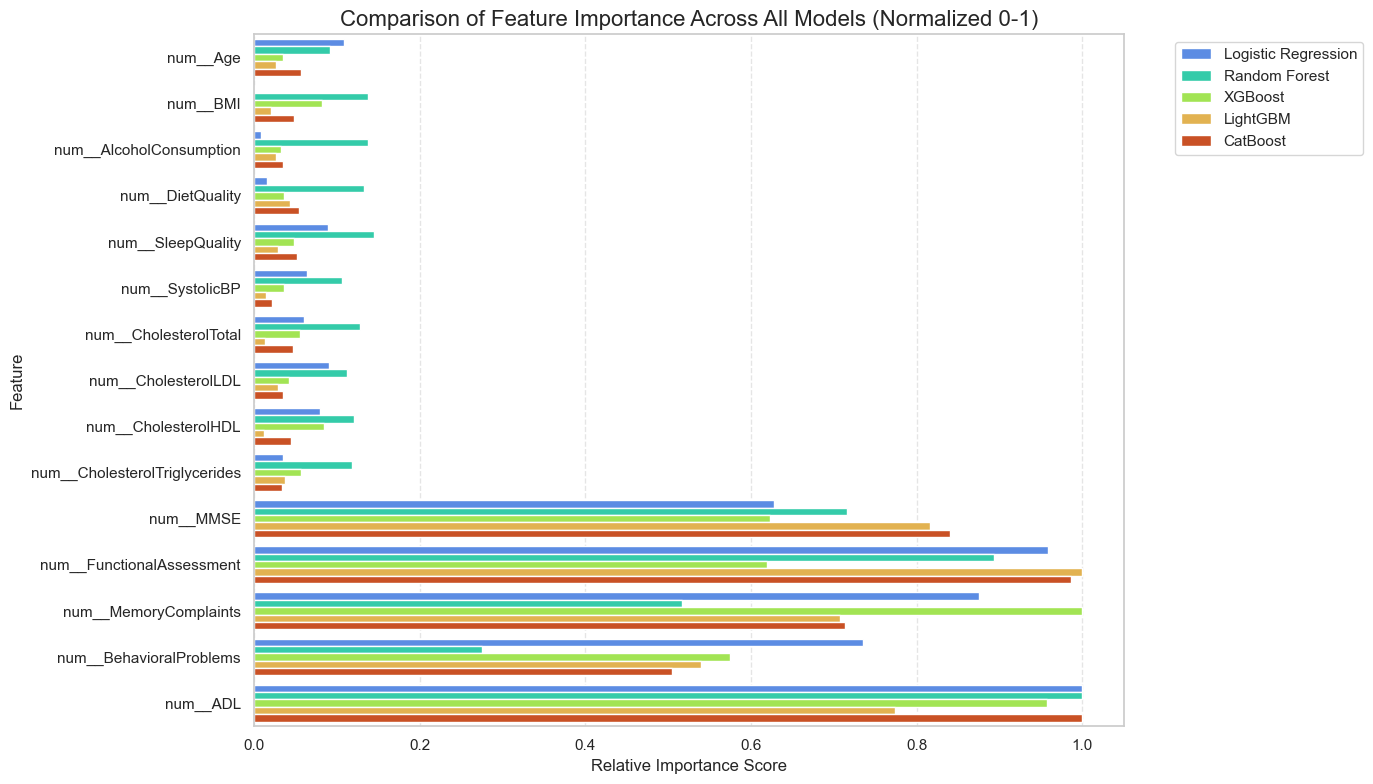

In [64]:
# =========================================
# Feature Importance: Individual and Comparative
# =========================================
importance_data = []

# 1. Loop through models to get individual plots and collect data
for name, clf in best_estimators.items():
    model = clf.named_steps["model"]
    feature_names = clf.named_steps["preprocessor"].get_feature_names_out()
    
    # Extract importances based on model type
    if hasattr(model, "feature_importances_"):
        importances = model.feature_importances_
    elif hasattr(model, "coef_"):
        importances = np.abs(model.coef_[0]) # Absolute value for interpretation
    else:
        continue 
    
    # Normalize (0-1) for the comparative plot data
    norm_importances = (importances - importances.min()) / (importances.max() - importances.min())
    
    # Store for global comparison
    for feat, imp in zip(feature_names, norm_importances):
        importance_data.append({"Model": name, "Feature": feat, "Importance": imp})
        
    # --- Individual Plot for each Model ---
    # Create a temporary DF for the top 15 of THIS model
    model_df = pd.DataFrame({"Feature": feature_names, "Importance": importances})
    model_df = model_df.sort_values(by="Importance", ascending=False).head(15)
    
    plt.figure(figsize=(10, 6))
    sns.barplot(data=model_df, x="Importance", y="Feature", hue="Feature", palette="viridis", legend=False)
    plt.title(f"Top 15 Feature Importances: {name}", fontsize=14)
    plt.xlabel("Importance Value" if "Regression" not in name else "Absolute Coefficient Value")
    plt.grid(axis='x', linestyle='--', alpha=0.3)
    plt.tight_layout()
    plt.show()

# 2. Comparative Plot (Normalized)
df_importance = pd.DataFrame(importance_data)

# Filter for the top 15 features overall (based on average importance)
top_overall = df_importance.groupby("Feature")["Importance"].mean().sort_values(ascending=False).head(15).index
df_importance_filtered = df_importance[df_importance["Feature"].isin(top_overall)]

plt.figure(figsize=(14, 8))
sns.barplot(data=df_importance_filtered, x="Importance", y="Feature", hue="Model", palette="turbo")
plt.title("Comparison of Feature Importance Across All Models (Normalized 0-1)", fontsize=16)
plt.xlabel("Relative Importance Score")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

In [65]:
# =========================================
# Save the Best Model
# =========================================

best_model_name = df_results["F1_Test"].idxmax()
best_model_obj = best_estimators[best_model_name]

print(f"--- BEST MODEL FOUND ---")
print(f"Model: {best_model_name}")
print(f"F1-Score (Test): {df_results.loc[best_model_name, 'F1_Test']:.4f}")
print(f"Overfitting Gap: {df_results.loc[best_model_name, 'F1_Gap']:.4f}")



--- BEST MODEL FOUND ---
Model: LightGBM
F1-Score (Test): 0.9369
Overfitting Gap: 0.0053


## SHAP and clinical validation

The SHAP analysis confirms that the LightGBM **model relies on a combination of clinical markers and specific demographic features** to reach its conclusions. I observe that features like scoring on **MMSE or ADL or Functional Assesment** have the highest impact on the model's output. 

Crucially, the SHAP values show a logical distribution: high values of clinical risk factors correctly push the model toward a positive diagnosis. This **alignment between model logic and medical intuition provides** an extra layer of **validation**, proving that the model is not just accurate, but also right for the right reasons.

--- SHAP Explanations for: LightGBM ---


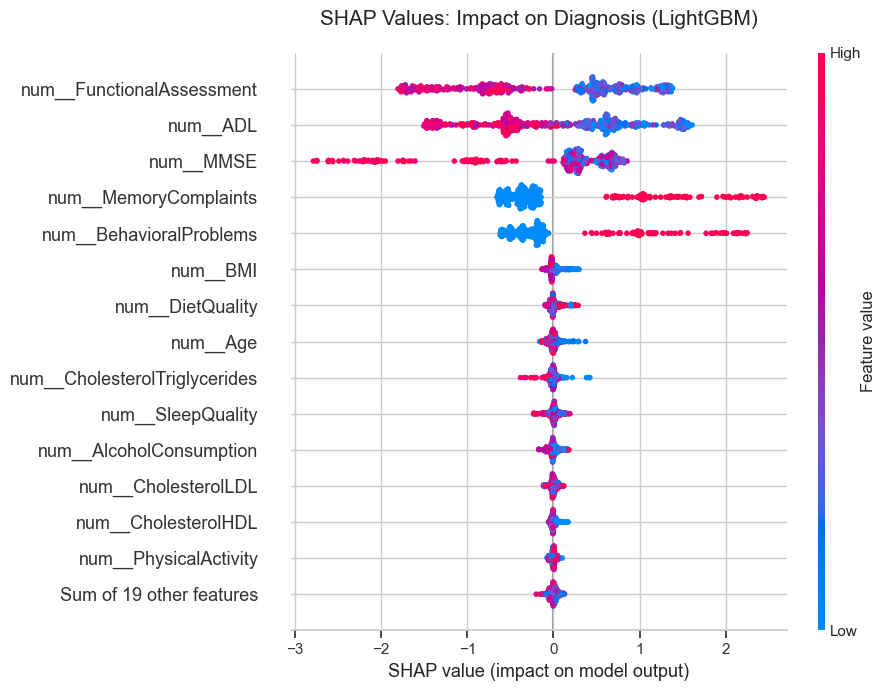

In [66]:
import shap

# 1. Identify the best model and its preprocessor
best_model_name = df_results["F1_Test"].idxmax()
best_clf = best_estimators[best_model_name]
model_step = best_clf.named_steps["model"]
preprocessor_step = best_clf.named_steps["preprocessor"]

# 2. Get feature names and transform test data
feature_names = preprocessor_step.get_feature_names_out()
X_test_transformed = preprocessor_step.transform(X_test)
X_test_df = pd.DataFrame(X_test_transformed, columns=feature_names)

# 3. Initialize SHAP Explainer
# shap.Explainer is a "smart" wrapper that chooses the right explainer for you
explainer = shap.Explainer(model_step, X_test_df)
shap_values = explainer(X_test_df)

# 4. Plotting
print(f"--- SHAP Explanations for: {best_model_name} ---")
plt.figure(figsize=(12, 8))

# If binary classification, ensure we plot the positive class (Alzheimer's)
if len(shap_values.shape) == 3:
    shap_values_to_plot = shap_values[:, :, 1]
else:
    shap_values_to_plot = shap_values

shap.plots.beeswarm(shap_values_to_plot, max_display=15, show=False)
plt.title(f"SHAP Values: Impact on Diagnosis ({best_model_name})", fontsize=15, pad=20)
plt.show()

In [67]:
import json
import joblib

# 1. Identify the best model and its preprocessor
best_model_name = df_metrics["F1-Score"].idxmax()
best_clf = best_estimators[best_model_name]

# 2. Extract best parameters with error handling
best_params = results[best_model_name].get("Best_Params", {})
if not best_params and hasattr(best_clf, "get_params"):
    # Estraiamo i parametri che iniziano con 'model__' e puliamo il nome
    raw_params = best_clf.get_params()
    best_params = {k.replace('model__', ''): v for k, v in raw_params.items() if k.startswith('model__')}

# 3. Dictionary to store metadata with error handling (Default values if keys are missing)
model_metadata = {
    "model_name": best_model_name,
    "best_params": best_params,
    "metrics": {
        "f1_test": results[best_model_name].get("F1-Score", 0),
        "auc_roc": results[best_model_name].get("AUC-ROC", 0),
        "f1_gap": results[best_model_name].get("F1_Gap", "Not Calculated")
    },
    "features_used": list(X.columns),
    "date": pd.Timestamp.now().strftime("%Y-%m-%d %H:%M")
}

# 4. Saving metadata to JSON with error handling
metadata_filename = f"metadata_{best_model_name.lower().replace(' ', '_')}.json"
with open(metadata_filename, "w") as f:
    json.dump(model_metadata, f, indent=4)

# 5. Salving the best model using Joblib
model_filename = f"best_model_{best_model_name.lower().replace(' ', '_')}.joblib"
joblib.dump(best_clf, model_filename)

print(f"Success! Saved metadata to: {metadata_filename}")
print(f" Success! Saved model to: {model_filename}")

Success! Saved metadata to: metadata_lightgbm.json
 Success! Saved model to: best_model_lightgbm.joblib


## Key achievements

- I identified **LightGBM as the champion model**, outperforming others in both **precision and sensitivity**.

- I verified that this **model minimizes False Positives and False Negatives** more effectively than competitors, ensuring higher **clinical utility**.

- I confirmed **model stability** by analyzing the **F1-Gap**, proving that the results are robust and generalizable.

- I established **model transparency by implementing SHAP analysis**, confirming that the top features driving the predictions align with clinical expectations and medical intuition.

---

## Next step:

- I will proceed to the **Fine-Tuning notebook**, where I will perform hyperparameter optimization specifically for LightGBM to push its predictive power even further.